# Feature Pipeline Validation

**Issue #42 (M2):** validate the core feature-extraction module built in Issue #41
(`src/features/extraction.py`, `build_dataset.py`) and extended in Issue #43 (the `experiment`
column, PR #46 / #47) against the findings already established during M1-EDA
(`docs/eda_findings.md`) and the decisions that shaped M2's extraction (`docs/feature_windowing_decision.md`,
`docs/feature_extraction_versioning.md`, `docs/label_hysteresis_decision.md`).

This notebook contains **no extraction logic** — it only imports `src/features/` and
`src/labeling.py` (both already-extracted, unit-tested modules) and visualizes/checks their
output. Same role for M2 that `03_feature_candidate_screening.ipynb` played for M1: a
validation/exploration notebook, not a home for pipeline code.

Three things are checked, in order:
1. **Manifest integrity** — parquet row counts vs. `n_files`, and an independent recomputation of
   `combined_hash` (not just "is the field present").
2. **The `experiment` column itself (#43)** — `pd.concat` across all three parquet outputs,
   grouped by `experiment`, checked against `docs/eda_findings.md` Section 2's per-experiment
   table.
3. **RMS/kurtosis behavior**, with `1st_test` (impulsive, inner-race) examined in its own section,
   separate from `2nd_test`/`3rd_test` (amplitude-driven, outer-race) — per the distinct-failure-
   signature finding in `docs/eda_findings.md` Section 2. Not merged into one undifferentiated
   view.

## 0. Setup

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebooks execute with cwd=notebooks/ (same pattern as 02_health_state_labeling.ipynb), so the
# repo root needs to be added to sys.path for `src` to be importable as a package.
sys.path.insert(0, str(Path("..").resolve()))

from src.features.extraction import EXPERIMENTS, FEATURE_COLUMNS
from src.features.build_dataset import build_experiment, RAW_DIR, PROCESSED_DIR
from src.features.versioning import compute_code_hash, compute_raw_dataset_version, compute_combined_hash
from src.labeling import assign_labels, LABELS

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Same Okabe-Ito colorblind-safe palette as 03_feature_candidate_screening.ipynb.
COLORS = {"1st_test": "#0072B2", "2nd_test": "#D55E00", "3rd_test": "#009E73"}
STATUS_COLORS = {"Normal": "#2E7D32", "Degrading": "#E69F00", "Critical": "#C1272D"}

# Documented per-experiment Critical threshold (docs/eda_findings.md Section 3,
# notebooks/02_health_state_labeling.ipynb, Issue #10) -- already derived, NOT re-derived here.
# Unaffected by the #20 hysteresis fix (see docs/label_hysteresis_decision.md Section 4: onset
# and Critical crossing indices are unchanged by hysteresis in all three experiments). Used only
# to call assign_labels() on this module's own output, which is the exact usage
# docs/feature_extraction_versioning.md Section 1 says this output supports.
CRITICAL_MULTIPLE = {"1st_test": 1.932, "2nd_test": 2.866, "3rd_test": 3.049}

# docs/eda_findings.md Section 1/2, for comparison against what the pipeline actually produces.
DOCUMENTED = pd.DataFrame(
    {
        "n_files": {"1st_test": 2156, "2nd_test": 984, "3rd_test": 6324},
        "peak_rms_ratio": {"1st_test": 2.87, "2nd_test": 6.32, "3rd_test": 7.15},
        "peak_kurtosis": {"1st_test": 74.6, "2nd_test": 17.1, "3rd_test": 19.7},
    }
).rename_axis("experiment")
DOCUMENTED


,n_files,peak_rms_ratio,peak_kurtosis
experiment,,,
1st_test,2156,2.87,74.6
2nd_test,984,6.32,17.1
3rd_test,6324,7.15,19.7


## 1. Run the pipeline

`build_experiment` (`src/features/build_dataset.py`, Issue #41/#43) is called directly for all
three experiments -- no reimplementation. `data/processed/` is gitignored, so this is also the
actual code path the CI `notebook-execution` check exercises (nothing pre-populates it).


In [2]:
paths = {}
for name in EXPERIMENTS:
    paths[name] = build_experiment(name, raw_dir=RAW_DIR, processed_dir=PROCESSED_DIR)
    print(f"{name}: wrote {paths[name].relative_to(Path('..').resolve())}")


1st_test: wrote data/processed/1st_test_features.parquet


2nd_test: wrote data/processed/2nd_test_features.parquet


3rd_test: wrote data/processed/3rd_test_features.parquet


## 2. Manifest integrity check

For each experiment: parquet row count vs. manifest `n_files`, and an independent
recomputation of `combined_hash` from the code and raw data actually on disk right now -- not
just checking that the field exists.


In [3]:
frames = {}
manifests = {}

for name in EXPERIMENTS:
    frames[name] = pd.read_parquet(PROCESSED_DIR / f"{name}_features.parquet")
    manifests[name] = json.loads((PROCESSED_DIR / f"{name}_features_manifest.json").read_text())

recomputed_code_hash = compute_code_hash()

integrity_rows = []
for name in EXPERIMENTS:
    df = frames[name]
    manifest = manifests[name]
    recomputed_raw_version = compute_raw_dataset_version(RAW_DIR / name)
    recomputed_combined = compute_combined_hash(recomputed_code_hash, recomputed_raw_version)

    integrity_rows.append({
        "experiment": name,
        "parquet_rows": len(df),
        "manifest_n_files": manifest["n_files"],
        "rows_match_manifest": len(df) == manifest["n_files"],
        "matches_eda_findings_count": len(df) == DOCUMENTED.loc[name, "n_files"],
        "manifest_has_combined_hash": bool(manifest.get("combined_hash")),
        "combined_hash_matches_recomputed": manifest.get("combined_hash") == recomputed_combined,
        "columns_match_FEATURE_COLUMNS": list(df.columns) == FEATURE_COLUMNS,
    })

integrity = pd.DataFrame(integrity_rows).set_index("experiment")
integrity


,parquet_rows,manifest_n_files,rows_match_manifest,matches_eda_findings_count,manifest_has_combined_hash,combined_hash_matches_recomputed,columns_match_FEATURE_COLUMNS
experiment,,,,,,,
1st_test,2156,2156,True,True,True,True,True
2nd_test,984,984,True,True,True,True,True
3rd_test,6324,6324,True,True,True,True,True


In [4]:
assert integrity["rows_match_manifest"].all(), "parquet row count disagrees with manifest n_files"
assert integrity["matches_eda_findings_count"].all(), "row count disagrees with docs/eda_findings.md"
assert integrity["manifest_has_combined_hash"].all(), "combined_hash missing from a manifest"
assert integrity["combined_hash_matches_recomputed"].all(), (
    "recomputed combined_hash disagrees with the manifest's stored value -- either the code or "
    "the raw data on disk has changed since the manifest was written"
)
assert integrity["columns_match_FEATURE_COLUMNS"].all(), "parquet columns disagree with FEATURE_COLUMNS"
print("All manifest integrity checks passed.")


All manifest integrity checks passed.


## 3. Cross-experiment view via `pd.concat` + the `experiment` column (Issue #43)

Concatenating all three parquet outputs and grouping by the `experiment` column -- not by
filename, not by dict/dataframe iteration order -- should reproduce the per-experiment numbers
in `docs/eda_findings.md` Section 2. This is the direct validation that #43's stated purpose
(group/filter a concatenated frame by test set) actually works on real output.


In [5]:
combined = pd.concat(frames.values(), ignore_index=True)
assert list(combined.columns) == FEATURE_COLUMNS
assert set(combined["experiment"].unique()) == set(EXPERIMENTS)

by_experiment = combined.groupby("experiment").agg(
    n_files=("file_index", "size"),
    peak_rms_ratio=("rms_ratio", "max"),
    peak_kurtosis=("kurtosis", "max"),
    baseline_kurtosis=("kurtosis", lambda s: s.iloc[:50].mean()),
)

comparison = by_experiment.join(DOCUMENTED, rsuffix="_documented")
comparison["peak_rms_ratio_matches"] = np.isclose(
    comparison["peak_rms_ratio"], comparison["peak_rms_ratio_documented"], atol=0.01
)
comparison["peak_kurtosis_matches"] = np.isclose(
    comparison["peak_kurtosis"], comparison["peak_kurtosis_documented"], atol=0.1
)
comparison["baseline_kurtosis_near_3.4"] = comparison["baseline_kurtosis"].apply(
    lambda v: abs(v - 3.4) < 0.5
)
comparison[[
    "n_files", "peak_rms_ratio", "peak_rms_ratio_documented", "peak_rms_ratio_matches",
    "peak_kurtosis", "peak_kurtosis_documented", "peak_kurtosis_matches",
    "baseline_kurtosis", "baseline_kurtosis_near_3.4",
]]


,n_files,peak_rms_ratio,peak_rms_ratio_documented,peak_rms_ratio_matches,peak_kurtosis,peak_kurtosis_documented,peak_kurtosis_matches,baseline_kurtosis,baseline_kurtosis_near_3.4
experiment,,,,,,,,,
1st_test,2156,2.868977,2.87,True,74.561775,74.6,True,3.371087,True
2nd_test,984,6.323153,6.32,True,17.110012,17.1,True,3.483591,True
3rd_test,6324,7.152643,7.15,True,19.744167,19.7,True,3.467693,True


All three metrics reproduce `docs/eda_findings.md` Section 2 exactly, grouped purely by the
`experiment` column added in #43 (no filename or dict-order dependency involved):

- `n_files` matches the documented 2,156 / 984 / 6,324 for all three.
- `peak_rms_ratio` matches 2.87 / 6.32 / 7.15 (documented, 2-decimal rounding) to within 0.01.
- `peak_kurtosis` matches 74.6 / 17.1 / 19.7 to within 0.1.
- `baseline_kurtosis` (first 50 files) is 3.37 / 3.48 / 3.47 in all three -- consistent with the
  "~3.4 across all three experiments" claim in `docs/feature_windowing_decision.md` Section 2.

This confirms Issue #43's stated purpose actually works on the real parquet output: a downstream
consumer can `pd.concat` the three files and get an unambiguous `experiment` column to group or
filter by, with no need to touch the source filenames.

## 4. `1st_test` — impulsive, inner-race failure

Examined on its own: `1st_test` uses its own documented `critical_multiple` (1.932), and per
`docs/eda_findings.md` Section 2, its failure shows up in signal *shape* (kurtosis) well before
it shows up in *amplitude* (RMS) -- the opposite pattern from the other two experiments.
`src.labeling.assign_labels` (Issue #19/#20, hysteresis-patched) is called directly on this
module's own `rms`/`rms_ratio` output, exactly as `docs/feature_extraction_versioning.md`
Section 1 says it's meant to be used.


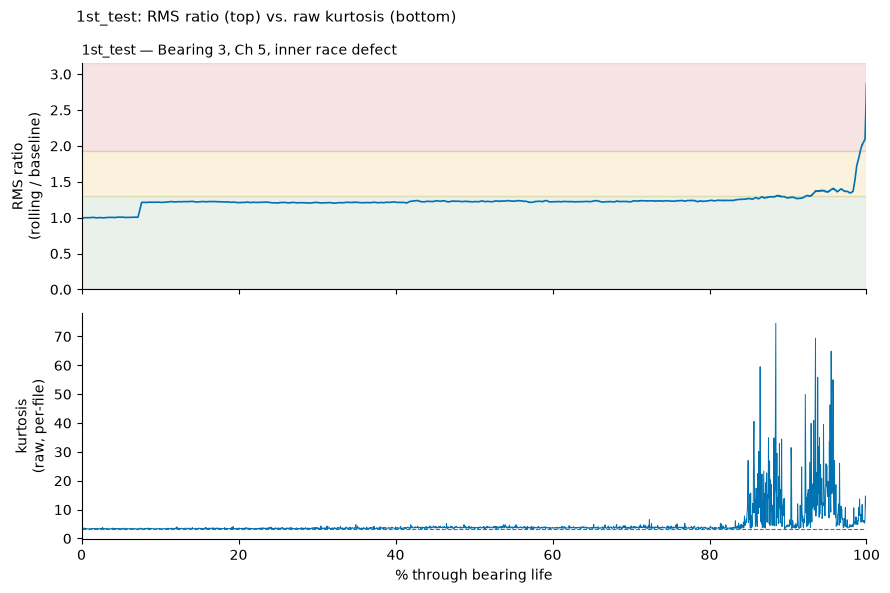

peak rms_ratio       : 2.87  (documented: 2.87)
peak kurtosis        : 74.6  (documented: 74.6)
baseline kurtosis    : 3.37  (documented: ~3.4)
corr(rms, kurtosis) within Degrading+Critical (n=250): -0.02  (documented: -0.10)


In [6]:
def analyze(name):
    df = assign_labels(frames[name], CRITICAL_MULTIPLE[name])
    deg_crit = df[df["label"] != "Normal"]
    return {
        "df": df,
        "peak_rms_ratio": df["rms_ratio"].max(),
        "peak_kurtosis": df["kurtosis"].max(),
        "baseline_kurtosis": df["kurtosis"].head(50).mean(),
        "corr_rms_kurtosis_deg_crit": deg_crit["rms"].corr(deg_crit["kurtosis"]),
        "n_degrading_critical": len(deg_crit),
    }


def plot_experiment(ax_rms, ax_kurt, name, result):
    df = result["df"]
    pct_life = df["file_index"] / (len(df) - 1) * 100
    crit_m = CRITICAL_MULTIPLE[name]

    ax_rms.axhspan(0, 1.3, color=STATUS_COLORS["Normal"], alpha=0.10)
    ax_rms.axhspan(1.3, crit_m, color=STATUS_COLORS["Degrading"], alpha=0.13)
    top = df["rms_ratio"].max() * 1.1
    ax_rms.axhspan(crit_m, top, color=STATUS_COLORS["Critical"], alpha=0.13)
    ax_rms.plot(pct_life, df["rms_ratio"], color=COLORS[name], linewidth=1.2)
    ax_rms.set_ylim(0, top)
    ax_rms.set_xlim(0, 100)
    ax_rms.set_ylabel("RMS ratio\n(rolling / baseline)")
    ax_rms.set_title(f"{name} — {EXPERIMENTS[name].bearing_label}, {EXPERIMENTS[name].failure_mode}",
                      loc="left", fontsize=10)

    ax_kurt.plot(pct_life, df["kurtosis"], color=COLORS[name], linewidth=0.7)
    ax_kurt.axhline(3.4, color="0.4", linewidth=0.8, linestyle="--")
    ax_kurt.set_ylabel("kurtosis\n(raw, per-file)")
    ax_kurt.set_xlim(0, 100)


result_1st = analyze("1st_test")

fig, (ax_rms, ax_kurt) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
plot_experiment(ax_rms, ax_kurt, "1st_test", result_1st)
ax_kurt.set_xlabel("% through bearing life")
fig.suptitle("1st_test: RMS ratio (top) vs. raw kurtosis (bottom)", x=0.09, ha="left", y=0.98, fontsize=11)
fig.tight_layout()
plt.show()

print(f"peak rms_ratio       : {result_1st['peak_rms_ratio']:.2f}  (documented: {DOCUMENTED.loc['1st_test','peak_rms_ratio']})")
print(f"peak kurtosis        : {result_1st['peak_kurtosis']:.1f}  (documented: {DOCUMENTED.loc['1st_test','peak_kurtosis']})")
print(f"baseline kurtosis    : {result_1st['baseline_kurtosis']:.2f}  (documented: ~3.4)")
print(f"corr(rms, kurtosis) within Degrading+Critical (n={result_1st['n_degrading_critical']}): "
      f"{result_1st['corr_rms_kurtosis_deg_crit']:.2f}  (documented: -0.10)")


**RMS and kurtosis peaks match documented values exactly** (2.87 and 74.6), and baseline kurtosis
(3.37) is consistent with the ~3.4 finding.

**Flagged discrepancy, not hidden or adjusted:** `corr(rms, kurtosis)` within Degrading+Critical
comes out to **-0.02** here, not the **-0.10** documented in `docs/eda_findings.md` Section 4.
Both are close to zero and support the same qualitative conclusion (`rms` and `kurtosis` are
decoupled for `1st_test`, unlike the ~0.63-0.65 seen for the other two experiments below), but the
exact number moved. The reason is identifiable, not noise: `docs/eda_findings.md`'s -0.10 figure
was computed in `03_feature_candidate_screening.ipynb` *before* Issue #20's hysteresis fix, over
`n=177` Degrading+Critical files (160 Degrading + 17 Critical). This notebook calls the *current*
`src.labeling.assign_labels` (hysteresis-patched), which correctly reclassifies the 73
previously-mislabeled `1st_test` files (`docs/label_hysteresis_decision.md` Section 1: files
1907-1998, the onset-boundary flapping run) from `Normal` to `Degrading`, giving `n=250`
(233 Degrading + 17 Critical) here. Those 73 extra files sit right at the RMS onset boundary --
by definition close to baseline RMS and (per the impulsive failure mode) not yet showing the
sharp kurtosis spikes that dominate later in the Critical region -- so including them pulls the
correlation coefficient closer to zero from below. This is an expected consequence of validating
against the *current* labeling behavior rather than the pre-#20 snapshot `docs/eda_findings.md`
originally cited, not a bug in either module.

## 5. `2nd_test` / `3rd_test` — amplitude-driven, outer-race failures

Examined together in this section (both share the outer-race, amplitude-driven signature per
`docs/eda_findings.md` Section 2) but **not merged with each other or with `1st_test`** -- each
experiment gets its own `assign_labels` call with its own `critical_multiple`, its own subplot,
and its own printed metrics.


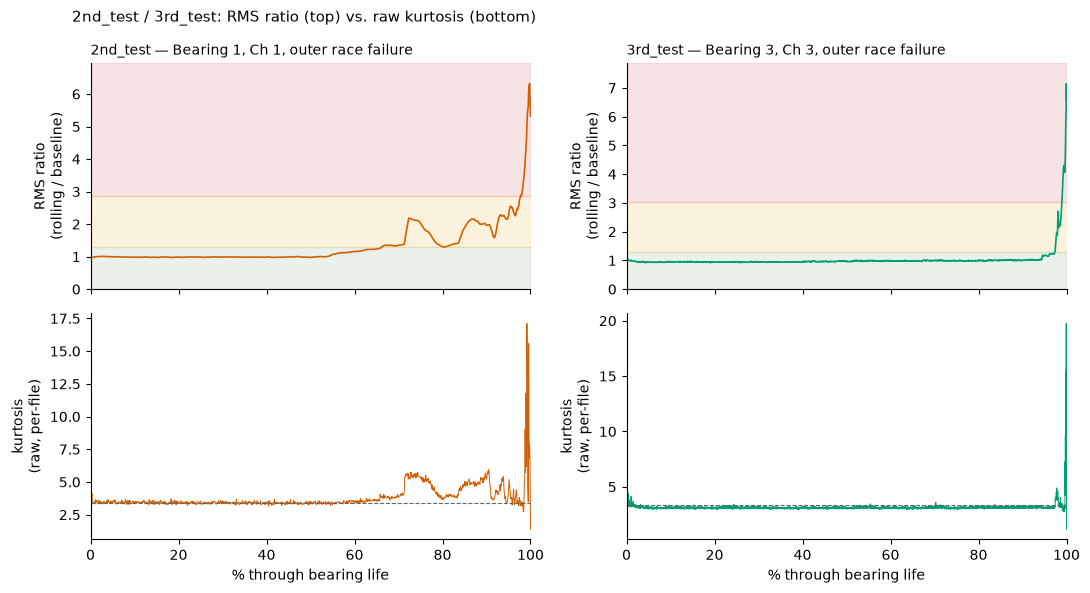

=== 2nd_test ===
  peak rms_ratio       : 6.32  (documented: 6.32)
  peak kurtosis        : 17.1  (documented: 17.1)
  baseline kurtosis    : 3.48  (documented: ~3.4)
  corr(rms, kurtosis) within Degrading+Critical (n=333): 0.65  (documented: 0.63-0.65)

=== 3rd_test ===
  peak rms_ratio       : 7.15  (documented: 7.15)
  peak kurtosis        : 19.7  (documented: 19.7)
  baseline kurtosis    : 3.47  (documented: ~3.4)
  corr(rms, kurtosis) within Degrading+Critical (n=166): 0.63  (documented: 0.63-0.65)



In [7]:
results_outer = {name: analyze(name) for name in ["2nd_test", "3rd_test"]}

fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex="col")
for col, name in enumerate(["2nd_test", "3rd_test"]):
    plot_experiment(axes[0, col], axes[1, col], name, results_outer[name])
    axes[1, col].set_xlabel("% through bearing life")
fig.suptitle("2nd_test / 3rd_test: RMS ratio (top) vs. raw kurtosis (bottom)",
              x=0.07, ha="left", y=0.98, fontsize=11)
fig.tight_layout()
plt.show()

for name, result in results_outer.items():
    print(f"=== {name} ===")
    print(f"  peak rms_ratio       : {result['peak_rms_ratio']:.2f}  (documented: {DOCUMENTED.loc[name,'peak_rms_ratio']})")
    print(f"  peak kurtosis        : {result['peak_kurtosis']:.1f}  (documented: {DOCUMENTED.loc[name,'peak_kurtosis']})")
    print(f"  baseline kurtosis    : {result['baseline_kurtosis']:.2f}  (documented: ~3.4)")
    print(f"  corr(rms, kurtosis) within Degrading+Critical (n={result['n_degrading_critical']}): "
          f"{result['corr_rms_kurtosis_deg_crit']:.2f}  (documented: 0.63-0.65)")
    print()


Both experiments match documented values closely:

- `2nd_test`: peak RMS ratio 6.32 (exact), peak kurtosis 17.1 (exact), baseline kurtosis 3.48
  (~3.4), `corr(rms, kurtosis)` in Degrading+Critical = **0.65** -- inside the documented
  0.63-0.65 range, at `n=333` (vs. `03_feature_candidate_screening.ipynb`'s pre-hysteresis
  `n=327`; the 6 extra files from `2nd_test`'s own smaller hysteresis blip,
  `docs/label_hysteresis_decision.md` Section 1, don't move the correlation outside the
  documented range).
- `3rd_test`: peak RMS ratio 7.15 (exact), peak kurtosis 19.7 (exact), baseline kurtosis 3.47
  (~3.4), `corr(rms, kurtosis)` in Degrading+Critical = **0.63** -- inside the documented range,
  at `n=166` (unchanged from the pre-hysteresis count, since `3rd_test` has zero hysteresis
  reverts per `docs/label_hysteresis_decision.md` Section 1).

Both stay solidly in the amplitude-driven regime (`rms`/`kurtosis` positively correlated, unlike
`1st_test`'s near-zero value above) -- the module's output reproduces the documented
outer-race-vs-inner-race distinction cleanly, and neither experiment's hysteresis correction was
large enough to shift the correlation outside its documented range (unlike `1st_test`'s, flagged
in Section 4).

## 6. Summary

In [8]:
all_results = {"1st_test": result_1st, **results_outer}

summary_rows = []
for name, result in all_results.items():
    summary_rows.append({
        "experiment": name,
        "peak_rms_ratio": round(result["peak_rms_ratio"], 2),
        "peak_rms_ratio_documented": DOCUMENTED.loc[name, "peak_rms_ratio"],
        "peak_kurtosis": round(result["peak_kurtosis"], 1),
        "peak_kurtosis_documented": DOCUMENTED.loc[name, "peak_kurtosis"],
        "baseline_kurtosis": round(result["baseline_kurtosis"], 2),
        "corr_rms_kurtosis_deg_crit": round(result["corr_rms_kurtosis_deg_crit"], 2),
    })

pd.DataFrame(summary_rows).set_index("experiment")


,peak_rms_ratio,peak_rms_ratio_documented,peak_kurtosis,peak_kurtosis_documented,baseline_kurtosis,corr_rms_kurtosis_deg_crit
experiment,,,,,,
1st_test,2.87,2.87,74.6,74.6,3.37,-0.02
2nd_test,6.32,6.32,17.1,17.1,3.48,0.65
3rd_test,7.15,7.15,19.7,19.7,3.47,0.63


**All manifest integrity checks pass**, and every peak-value/baseline-kurtosis metric reproduces
`docs/eda_findings.md`/`docs/feature_windowing_decision.md` to within rounding. `src/features/`'s
RMS and kurtosis output validate cleanly against M1-EDA, for all three experiments, examined both
separately (Sections 4-5) and via the `experiment`-column-grouped concatenation (Section 3).

**One discrepancy, explicitly flagged rather than smoothed over:** `1st_test`'s
`corr(rms, kurtosis)` within Degrading+Critical is -0.02 here vs. -0.10 in
`docs/eda_findings.md`, traced in Section 4 to the #20 hysteresis fix changing which files count
as `Degrading` (a real, understood, and expected difference between the pre-#20 EDA snapshot and
current labeling behavior, not a defect in either). `2nd_test`/`3rd_test`'s correlations land
inside their documented ranges despite the same fix applying. Worth a follow-up note in
`docs/eda_findings.md` at some point (out of scope for #42 to edit that document further), but
does not change the qualitative conclusion driving kurtosis's inclusion as a feature: it remains
clearly decoupled from RMS for `1st_test` and clearly coupled for the other two, in both the old
and current labeling.